<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 🌲🌲🌲 Random Forest para Auditores Bancarios


## 1. FUNDAMENTOS TEÓRICOS

### 1.1 ¿Qué es Random Forest?

**Random Forest** es un algoritmo de *ensemble* que combina múltiples árboles de decisión entrenados de forma independiente. La predicción final se obtiene por **votación mayoritaria** (clasificación) o **promedio** (regresión).

Dos principios clave:
- **Bagging (Bootstrap Aggregating):** Cada árbol se entrena con una muestra aleatoria CON reemplazo del dataset original. Aproximadamente el 63.2% de los datos originales aparecen en cada muestra, y el 36.8% restante forma el **OOB set** (Out-of-Bag).
- **Feature Randomness:** En cada nodo de cada árbol, solo se evalúa un subconjunto aleatorio de variables (`max_features = sqrt(p)` por defecto). Esto decorrelaciona los árboles y reduce la varianza.

### 1.2 Matemática del Ensemble

Para **B árboles** con predicción individual $T_b(x)$:

**Clasificación:** $\hat{y}(x) = \text{moda}\{T_1(x), T_2(x), ..., T_B(x)\}$

**Probabilidad:** $\hat{p}(x) = \frac{1}{B} \sum_{b=1}^{B} P_b(Y=1|x)$

**Reducción de varianza:** $Var(\bar{T}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$

Donde $\rho$ es la correlación entre árboles. A menor correlación (más aleatoriedad en features), menor varianza del ensemble.

### 1.3 Out-of-Bag (OOB) Score

Cada árbol valida en su ~37% de datos no usados. El **OOB Score** permite validar el modelo sin necesidad de test set separado: clave cuando el dataset es pequeño.

### 1.4 Importancia de Variables

**MDI (Mean Decrease Impurity):** Suma la reducción de impureza Gini que aporta cada variable en todos los árboles. Rápida pero sesgada hacia variables de alta cardinalidad.

**MDA (Permutation Importance):** Permuta aleatoriamente los valores de cada variable en el OOB set y mide la caída de accuracy. Más robusta y recomendada para auditoría.

### 1.5 Aplicaciones Bancarias

| Caso de Uso | Ventaja de RF |
|-------------|---------------|
| Scoring de crédito | Alta precisión, robusto ante outliers |
| Detección de fraude | Maneja bien clases desbalanceadas |
| AML / KYC | Captura patrones complejos no lineales |
| Stress Testing | Más estable que modelos individuales |
| LGD / PD / EAD | Precisión superior a regresión logística |

### 1.6 Hiperparámetros Clave

| Parámetro | Efecto | Valor típico bancario |
|-----------|--------|----------------------|
| `n_estimators` | Número de árboles | 200-500 |
| `max_features` | Variables por nodo | 'sqrt' |
| `max_depth` | Profundidad de cada árbol | None o 10-20 |
| `min_samples_leaf` | Mínimo muestras en hoja | 5-20 |
| `oob_score` | Calcular OOB | True |
| `class_weight` | Ajuste desbalanceo | 'balanced' |

### 1.7 Ventajas y Limitaciones para Auditores

| Ventajas | Limitaciones |
|----------|--------------|
| Alta precisión predictiva | Menos interpretable que árbol simple |
| Robusto ante outliers y ruido | Lento para datasets muy grandes |
| Importancia de variables integrada | Probabilidades no bien calibradas |
| OOB como validación gratuita | Elevado uso de memoria |
| No requiere escalado | Sesgo en importancia MDI |

## 2. CONFIGURACIÓN Y LIBRERÍAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, pointbiserialr

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 3. CARGA DE DATOS DE AUDITORÍA BANCARIA

In [3]:
# === Carga del dataset común de auditoría bancaria ===
# Este CSV es el generado en el script introductorio de datos y desbalanceo.
# Debe estar en la misma carpeta que este notebook.

from pathlib import Path

CSV_PATH = Path("../../data/auditoria_bancaria_desbalanceada.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/mnt/data/auditoria_bancaria_desbalanceada.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "No se encuentra 'auditoria_bancaria_desbalanceada.csv'. "
        "Coloca el CSV en la misma carpeta que este notebook."
    )

df = pd.read_csv(CSV_PATH)

# Variable respuesta del dataset nuevo
TARGET = "riesgo_auditoria"

# Identificador técnico: no debe entrar como predictor
ID_COLS = [c for c in ["id_operacion"] if c in df.columns]

# Separación X/y
X_raw = df.drop(columns=[TARGET] + ID_COLS)
y = df[TARGET].astype(int)

# Encoding de variables categóricas para Random Forest
cat_cols = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Función auxiliar para generar nuevos periodos con la MISMA estructura del CSV.
# Se usa más adelante en los apartados de monitoring, PSI y validación.
def generar_portafolio_bancario(n=6000, seed=42):
    rng = np.random.default_rng(seed)
    base = df.sample(n=n, replace=True, random_state=seed).reset_index(drop=True).copy()
    if "id_operacion" in base.columns:
        base["id_operacion"] = np.arange(1, n + 1)

    # Pequeña variabilidad realista para no clonar exactamente los mismos registros
    for col in base.select_dtypes(include=[np.number]).columns:
        if col in [TARGET, "id_operacion"]:
            continue
        std = df[col].std()
        if pd.notna(std) and std > 0:
            ruido = rng.normal(0, 0.03 * std, n)
            base[col] = base[col] + ruido
            if pd.api.types.is_integer_dtype(df[col]):
                base[col] = np.round(base[col]).astype(int)
    return base

def preparar_X_y_desde_df(df_nuevo):
    """Prepara un dataframe nuevo con las mismas columnas que X."""
    X_n_raw = df_nuevo.drop(columns=[TARGET] + [c for c in ID_COLS if c in df_nuevo.columns])
    y_n = df_nuevo[TARGET].astype(int)
    X_n = pd.get_dummies(X_n_raw, columns=[c for c in cat_cols if c in X_n_raw.columns], drop_first=True)
    for col in X.columns:
        if col not in X_n.columns:
            X_n[col] = 0
    X_n = X_n[X.columns]
    return X_n, y_n

print("✅ Dataset cargado correctamente")
print(f"Archivo usado: {CSV_PATH}")
print(f"Dataset: {len(df):,} operaciones | Riesgo auditoría: {df[TARGET].mean()*100:.2f}%")
print(f"Variables originales: {X_raw.shape[1]} | Variables tras dummies: {X.shape[1]}")
print(f"Variables numéricas: {len(num_cols)} | Variables categóricas: {len(cat_cols)}")
print("\nDistribución de la variable respuesta:")
print(y.value_counts(normalize=True).rename("proporción").round(4))

df.head()

✅ Dataset cargado correctamente
Archivo usado: ..\..\data\auditoria_bancaria_desbalanceada.csv
Dataset: 15,000 operaciones | Riesgo auditoría: 6.32%
Variables originales: 15 | Variables tras dummies: 25
Variables numéricas: 10 | Variables categóricas: 5

Distribución de la variable respuesta:
riesgo_auditoria
0    0.9368
1    0.0632
Name: proporción, dtype: float64


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


## 4. ARBOL INDIVIDUAL vs RANDOM FOREST — DEMOSTRACION DE ESTABILIDAD

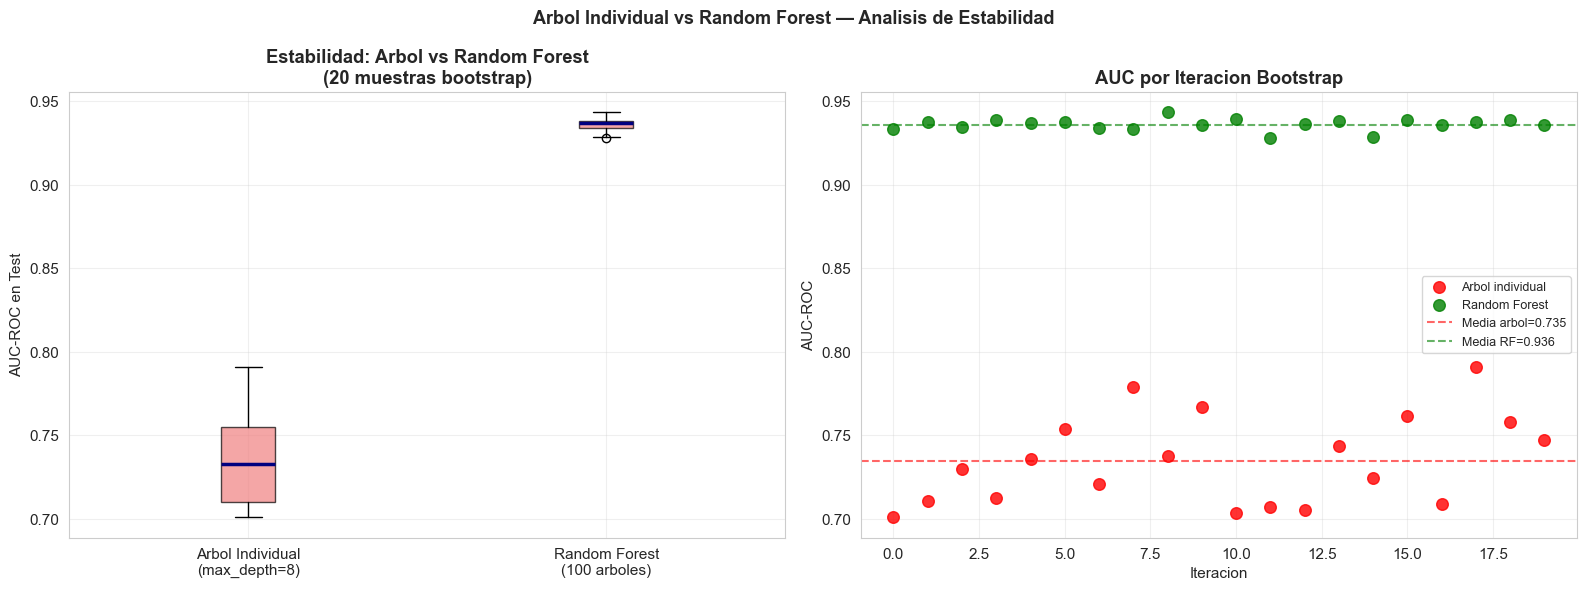

Arbol Individual  → Media: 0.7350 | Std: 0.0263
Random Forest     → Media: 0.9360 | Std: 0.0036
RF es 7.4x mas estable que el arbol individual


In [4]:
n_iter = 20
aucs_tree, aucs_rf = [], []

for i in range(n_iter):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
    tree = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=i)
    tree.fit(Xb, yb)
    aucs_tree.append(roc_auc_score(y_test, tree.predict_proba(X_test)[:,1]))
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=i, n_jobs=-1)
    rf.fit(Xb, yb)
    aucs_rf.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].boxplot([aucs_tree, aucs_rf],
                labels=['Arbol Individual\n(max_depth=8)', 'Random Forest\n(100 arboles)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2.5))
axes[0].set_ylabel('AUC-ROC en Test')
axes[0].set_title('Estabilidad: Arbol vs Random Forest\n(20 muestras bootstrap)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(n_iter), aucs_tree, color='red', label='Arbol individual', alpha=0.8, s=70)
axes[1].scatter(range(n_iter), aucs_rf, color='green', label='Random Forest', alpha=0.8, s=70)
axes[1].axhline(np.mean(aucs_tree), color='red', linestyle='--', alpha=0.6, label=f'Media arbol={np.mean(aucs_tree):.3f}')
axes[1].axhline(np.mean(aucs_rf), color='green', linestyle='--', alpha=0.6, label=f'Media RF={np.mean(aucs_rf):.3f}')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC por Iteracion Bootstrap', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Arbol Individual vs Random Forest — Analisis de Estabilidad', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Arbol Individual  → Media: {np.mean(aucs_tree):.4f} | Std: {np.std(aucs_tree):.4f}")
print(f"Random Forest     → Media: {np.mean(aucs_rf):.4f} | Std: {np.std(aucs_rf):.4f}")
print(f"RF es {np.std(aucs_tree)/np.std(aucs_rf):.1f}x mas estable que el arbol individual")

## 5. CONVERGENCIA — CUANTOS ARBOLES NECESITAMOS?

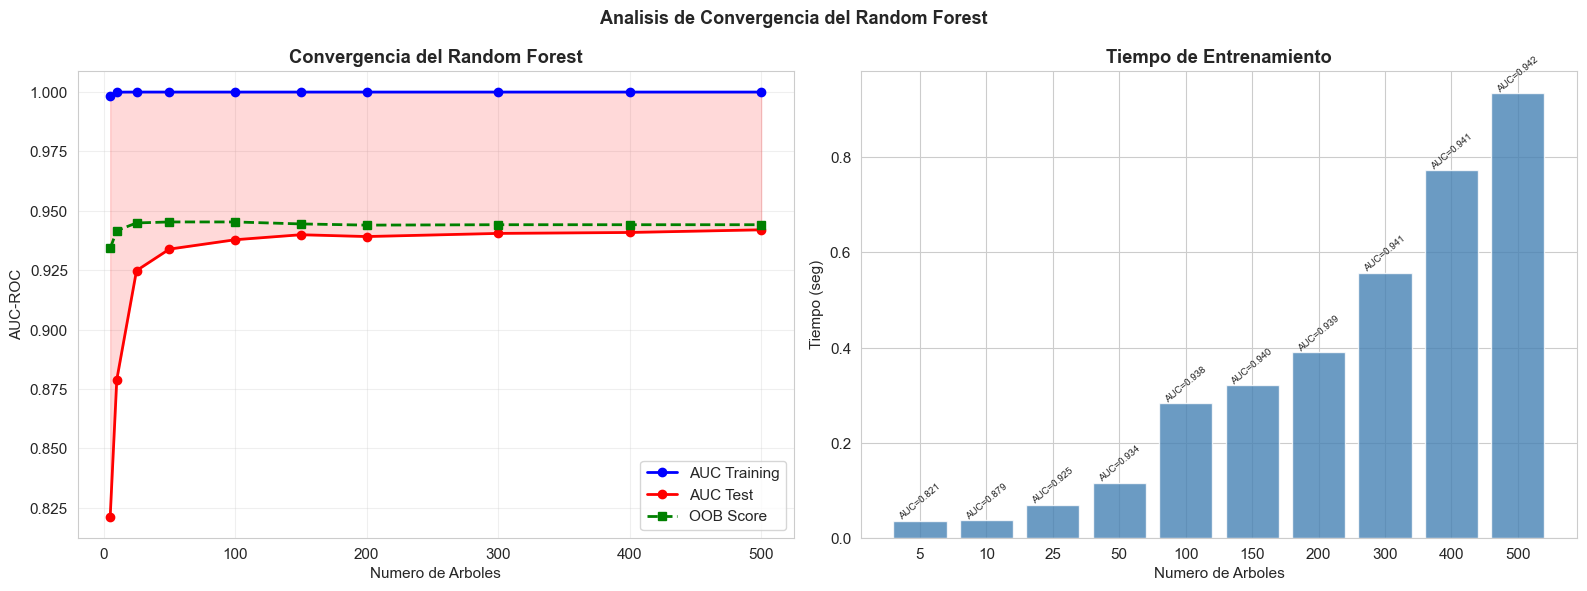

Recomendacion bancaria: 200-300 arboles como compromiso optimo rendimiento/tiempo


In [5]:
n_trees_range = [5, 10, 25, 50, 100, 150, 200, 300, 400, 500]
auc_train_list, auc_test_list, oob_list, tiempo_list = [], [], [], []

for n_trees in n_trees_range:
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=n_trees, max_features='sqrt',
                                 class_weight='balanced', oob_score=True,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    tiempo_list.append(time.time() - t0)
    auc_train_list.append(roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]))
    auc_test_list.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
    oob_list.append(rf.oob_score_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(n_trees_range, auc_train_list, 'b-o', label='AUC Training', lw=2)
axes[0].plot(n_trees_range, auc_test_list, 'r-o', label='AUC Test', lw=2)
axes[0].plot(n_trees_range, oob_list, 'g--s', label='OOB Score', lw=2)
axes[0].fill_between(n_trees_range, auc_train_list, auc_test_list, alpha=0.15, color='red')
axes[0].set_xlabel('Numero de Arboles'); axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Convergencia del Random Forest', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(n_trees_range)), tiempo_list, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(n_trees_range))); axes[1].set_xticklabels(n_trees_range)
axes[1].set_xlabel('Numero de Arboles'); axes[1].set_ylabel('Tiempo (seg)')
axes[1].set_title('Tiempo de Entrenamiento', fontweight='bold')
for i, (t, auc_v) in enumerate(zip(tiempo_list, auc_test_list)):
    axes[1].text(i, t+0.003, f'AUC={auc_v:.3f}', ha='center', fontsize=7, rotation=40)

plt.suptitle('Analisis de Convergencia del Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("Recomendacion bancaria: 200-300 arboles como compromiso optimo rendimiento/tiempo")

## 6. MODELO RANDOM FOREST OPTIMO CON TUNING

In [6]:
param_dist = {
    'n_estimators': randint(100, 400),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'max_depth': [None, 8, 12, 16, 20],
    'min_samples_leaf': randint(2, 25),
    'min_samples_split': randint(5, 50),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=40, cv=cv,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1
)
random_search.fit(X_train, y_train)
rf_opt = random_search.best_estimator_

y_pred = rf_opt.predict(X_test)
y_prob = rf_opt.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
gini = 2*auc - 1

print("RANDOM FOREST OPTIMO")
print("="*50)
for k,v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nAUC CV:    {random_search.best_score_:.4f}")
print(f"AUC Test:  {auc:.4f}")
print(f"Gini:      {gini*100:.1f}%")
print(f"OOB Score: {rf_opt.oob_score_:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Corriente','Default']))

RANDOM FOREST OPTIMO
  max_depth: 12
  max_features: sqrt
  min_samples_leaf: 6
  min_samples_split: 30
  n_estimators: 354

AUC CV:    0.9508
AUC Test:  0.9394
Gini:      87.9%
OOB Score: 0.9529

              precision    recall  f1-score   support

   Corriente       0.98      0.96      0.97      2810
     Default       0.58      0.74      0.65       190

    accuracy                           0.95      3000
   macro avg       0.78      0.85      0.81      3000
weighted avg       0.96      0.95      0.95      3000



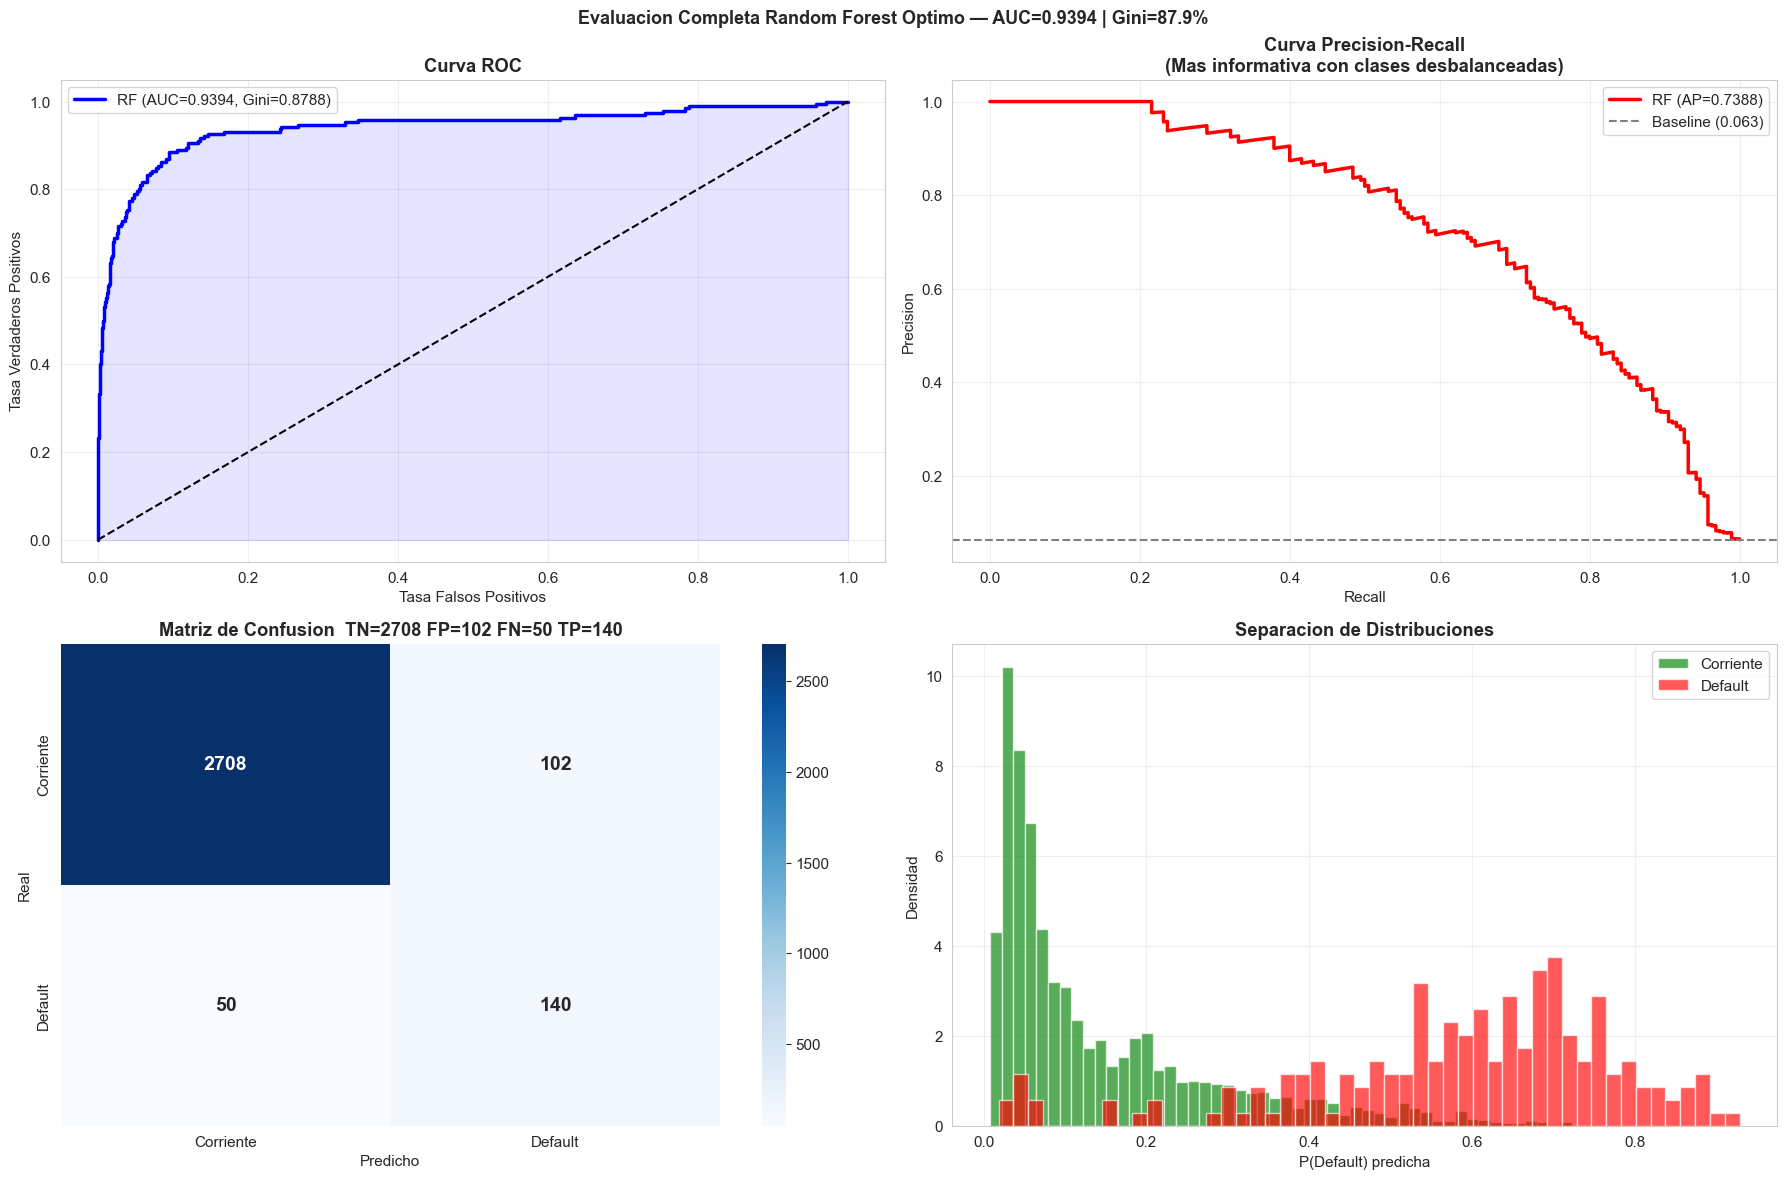

In [7]:
# Dashboard de evaluacion completa
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0,0].plot(fpr, tpr, 'b-', lw=2.5, label=f'RF (AUC={auc:.4f}, Gini={gini:.4f})')
axes[0,0].plot([0,1],[0,1],'k--')
axes[0,0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0,0].set_xlabel('Tasa Falsos Positivos'); axes[0,0].set_ylabel('Tasa Verdaderos Positivos')
axes[0,0].set_title('Curva ROC', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[0,1].plot(recall, precision, 'r-', lw=2.5, label=f'RF (AP={ap:.4f})')
axes[0,1].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[0,1].set_xlabel('Recall'); axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Curva Precision-Recall\n(Mas informativa con clases desbalanceadas)', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Corriente','Default'], yticklabels=['Corriente','Default'],
            annot_kws={'size':14,'weight':'bold'})
axes[1,0].set_title(f'Matriz de Confusion  TN={tn} FP={fp} FN={fn} TP={tp}', fontweight='bold')
axes[1,0].set_ylabel('Real'); axes[1,0].set_xlabel('Predicho')

# Distribucion de probabilidades
axes[1,1].hist(y_prob[y_test==0], bins=50, alpha=0.65, color='green', label='Corriente', density=True)
axes[1,1].hist(y_prob[y_test==1], bins=50, alpha=0.65, color='red', label='Default', density=True)
axes[1,1].set_xlabel('P(Default) predicha'); axes[1,1].set_ylabel('Densidad')
axes[1,1].set_title('Separacion de Distribuciones', fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Evaluacion Completa Random Forest Optimo — AUC={auc:.4f} | Gini={gini*100:.1f}%', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. IMPORTANCIA DE VARIABLES — ANALISIS TRIPLE

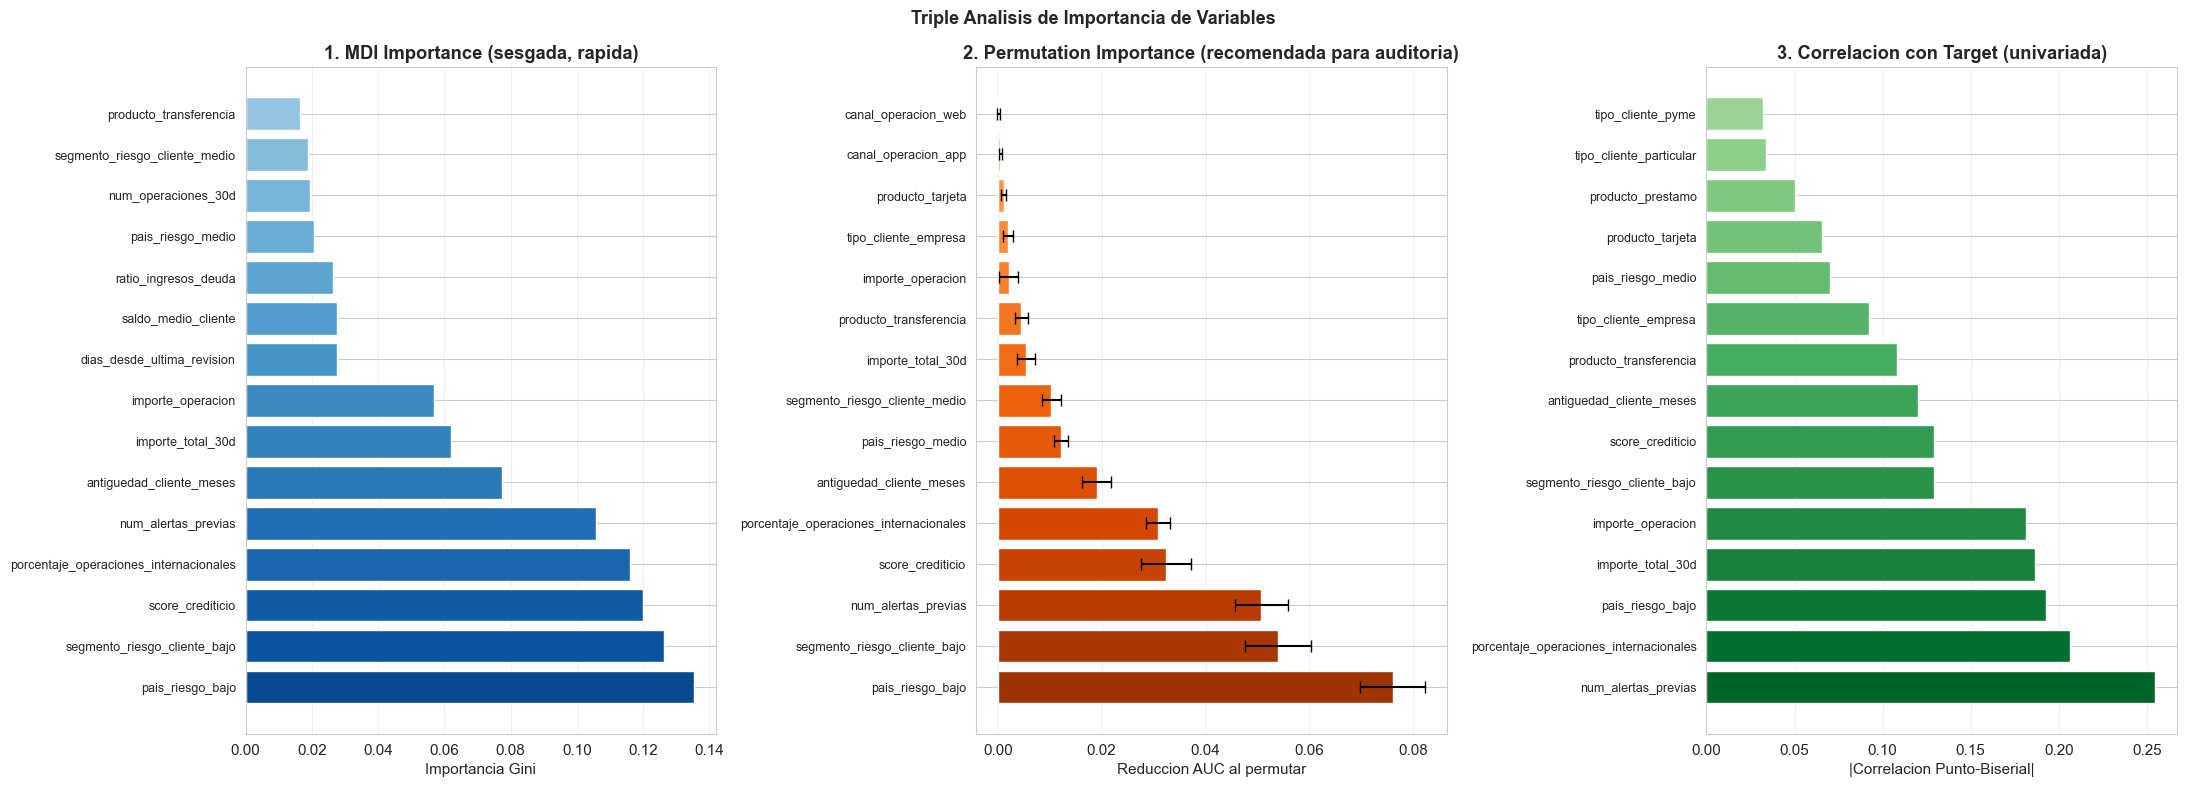

TOP 10 VARIABLES POR RANKING PROMEDIO:
                                        Rank_MDI  Rank_Perm  Rank_Corr  Rank_Promedio
pais_riesgo_bajo                               1          1          3            1.7
num_alertas_previas                            5          3          1            3.0
segmento_riesgo_cliente_bajo                   2          2          6            3.3
porcentaje_operaciones_internacionales         4          5          2            3.7
score_crediticio                               3          4          7            4.7
antiguedad_cliente_meses                       6          6          8            6.7
importe_total_30d                              7          9          4            6.7
importe_operacion                              8         11          5            8.0
pais_riesgo_medio                             12          7         11           10.0
producto_transferencia                        15         10          9           11.3


In [8]:
# MDI
mdi_imp = pd.Series(rf_opt.feature_importances_, index=X.columns).sort_values(ascending=False)

# Permutation Importance
perm_result = permutation_importance(rf_opt, X_test, y_test, n_repeats=20,
                                       random_state=RANDOM_STATE, scoring='roc_auc')
perm_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia_Media': perm_result.importances_mean,
    'Importancia_Std': perm_result.importances_std
}).sort_values('Importancia_Media', ascending=False)

# Correlacion punto-biserial
corr_target = {col: abs(pointbiserialr(X_test[col], y_test)[0]) for col in X.columns}
corr_series = pd.Series(corr_target).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
top_n = 15

top_mdi = mdi_imp.head(top_n)
axes[0].barh(range(top_n), top_mdi.values, color=plt.cm.Blues(np.linspace(0.4,0.9,top_n))[::-1])
axes[0].set_yticks(range(top_n)); axes[0].set_yticklabels(top_mdi.index, fontsize=9)
axes[0].set_title('1. MDI Importance (sesgada, rapida)', fontweight='bold')
axes[0].set_xlabel('Importancia Gini'); axes[0].grid(True, alpha=0.3, axis='x')

top_perm = perm_df.head(top_n)
axes[1].barh(range(top_n), top_perm['Importancia_Media'], xerr=top_perm['Importancia_Std'],
             color=plt.cm.Oranges(np.linspace(0.4,0.9,top_n))[::-1], capsize=4)
axes[1].set_yticks(range(top_n)); axes[1].set_yticklabels(top_perm['Variable'], fontsize=9)
axes[1].set_title('2. Permutation Importance (recomendada para auditoria)', fontweight='bold')
axes[1].set_xlabel('Reduccion AUC al permutar'); axes[1].grid(True, alpha=0.3, axis='x')

top_corr = corr_series.head(top_n)
axes[2].barh(range(top_n), top_corr.values, color=plt.cm.Greens(np.linspace(0.4,0.9,top_n))[::-1])
axes[2].set_yticks(range(top_n)); axes[2].set_yticklabels(top_corr.index, fontsize=9)
axes[2].set_title('3. Correlacion con Target (univariada)', fontweight='bold')
axes[2].set_xlabel('|Correlacion Punto-Biserial|'); axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Triple Analisis de Importancia de Variables', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Ranking comparativo
rank_mdi = {v:i+1 for i,v in enumerate(mdi_imp.index)}
rank_perm = {v:i+1 for i,v in enumerate(perm_df['Variable'])}
rank_corr = {v:i+1 for i,v in enumerate(corr_series.index)}
ranking_df = pd.DataFrame({'Rank_MDI':rank_mdi,'Rank_Perm':rank_perm,'Rank_Corr':rank_corr})
ranking_df['Rank_Promedio'] = ranking_df.mean(axis=1)
print("TOP 10 VARIABLES POR RANKING PROMEDIO:")
print(ranking_df.sort_values('Rank_Promedio').head(10).round(1).to_string())

## 8. CALIBRACION DE PROBABILIDADES

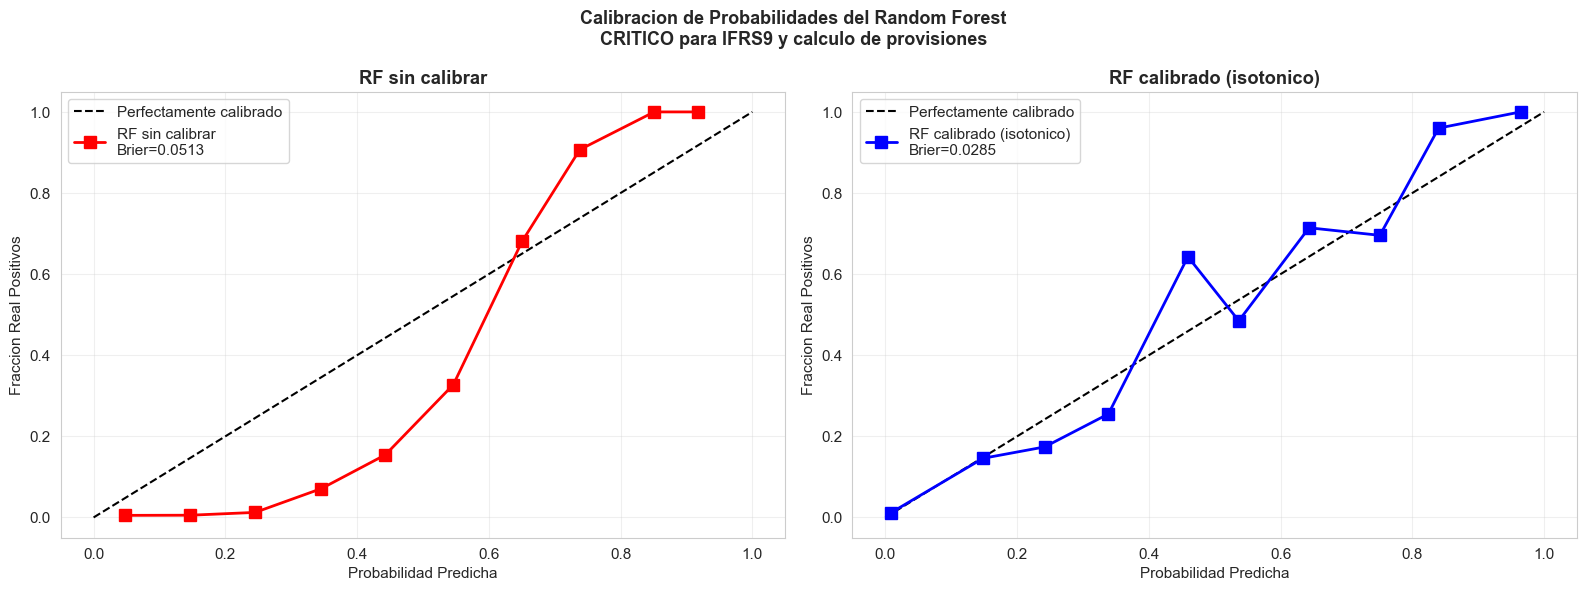

Brier Score sin calibrar: 0.0513
Brier Score calibrado:    0.0285

Para usos bancarios donde se necesitan PDs reales (IFRS9, Basilea): SIEMPRE calibrar


In [9]:
# RF tiende a producir probabilidades no calibradas (comprimidas hacia 0.5)
rf_cal = CalibratedClassifierCV(rf_opt, method='isotonic', cv=5)
rf_cal.fit(X_train, y_train)
y_prob_cal = rf_cal.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for prob, label, color, ax in [(y_prob,'RF sin calibrar','red',axes[0]),(y_prob_cal,'RF calibrado (isotonico)','blue',axes[1])]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    brier = brier_score_loss(y_test, prob)
    ax.plot([0,1],[0,1],'k--', label='Perfectamente calibrado')
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=2, markersize=8, label=f'{label}\nBrier={brier:.4f}')
    ax.set_xlabel('Probabilidad Predicha'); ax.set_ylabel('Fraccion Real Positivos')
    ax.set_title(label, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Calibracion de Probabilidades del Random Forest\nCRITICO para IFRS9 y calculo de provisiones', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Brier Score sin calibrar: {brier_score_loss(y_test, y_prob):.4f}")
print(f"Brier Score calibrado:    {brier_score_loss(y_test, y_prob_cal):.4f}")
print("\nPara usos bancarios donde se necesitan PDs reales (IFRS9, Basilea): SIEMPRE calibrar")

## 9. MONITOREO EN PRODUCCION — PSI TRIMESTRAL

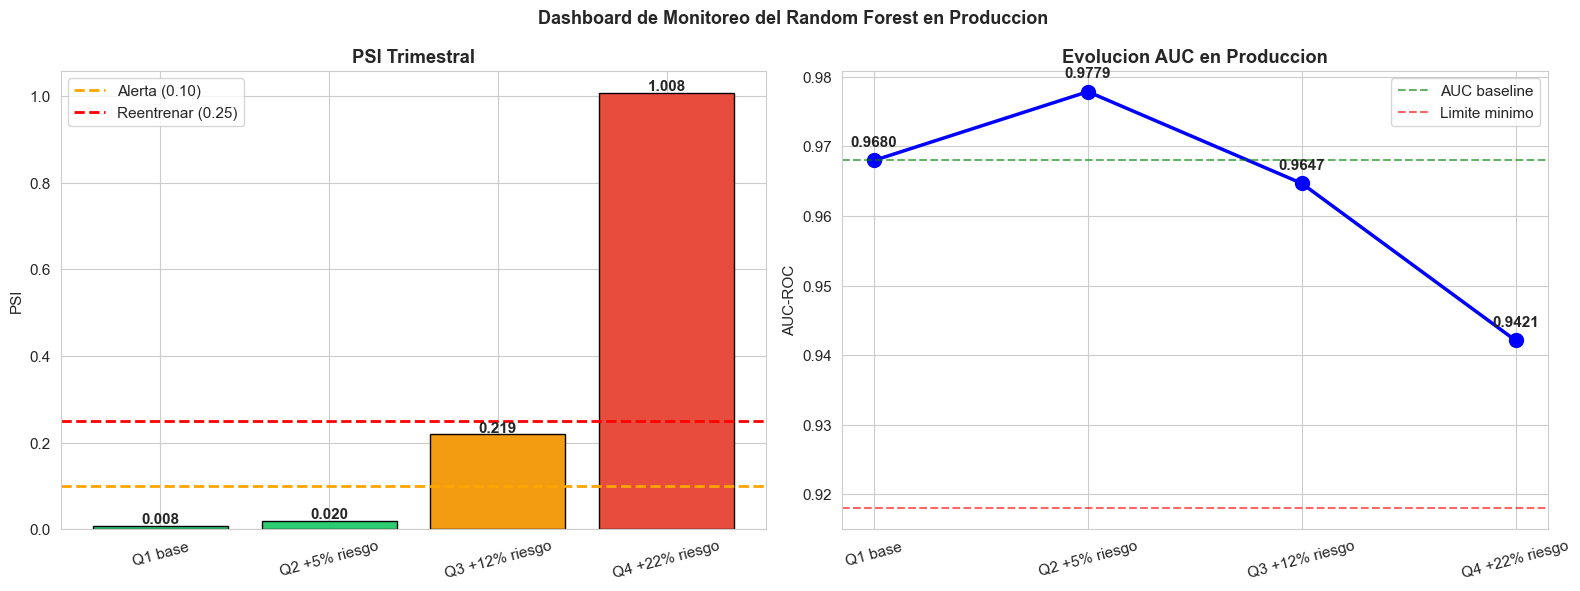


RESUMEN MONITOREO:
  Q1 base: PSI=0.008 | AUC=0.9680 -> OK
  Q2 +5% riesgo: PSI=0.020 | AUC=0.9779 -> OK
  Q3 +12% riesgo: PSI=0.219 | AUC=0.9647 -> REVISAR
  Q4 +22% riesgo: PSI=1.008 | AUC=0.9421 -> REENTRENAR


In [11]:
def calcular_psi(scores_ref, scores_actual, n_bins=10):
    bins = np.percentile(scores_ref, np.linspace(0, 100, n_bins+1))
    bins[0] = -np.inf; bins[-1] = np.inf

    ref_counts = pd.cut(scores_ref, bins=bins).value_counts().sort_index()
    ref_pct = (ref_counts / ref_counts.sum()).clip(lower=1e-4)

    act_counts = pd.cut(scores_actual, bins=bins).value_counts().sort_index()
    act_pct = (act_counts / act_counts.sum()).clip(lower=1e-4)
    return ((act_pct - ref_pct) * np.log(act_pct / ref_pct)).sum()

periodos = ['Q1 base', 'Q2 +5% riesgo', 'Q3 +12% riesgo', 'Q4 +22% riesgo']
deterioros = [0.0, 0.05, 0.12, 0.22]
psi_vals, auc_vals = [], []

for det, periodo in zip(deterioros, periodos):
    df_nuevo = generar_portafolio_bancario(n=2000, seed=int(det*100)+1)

    # Simulación de deterioro compatible con el dataset nuevo de auditoría
    if 'score_crediticio' in df_nuevo.columns:
        df_nuevo['score_crediticio'] = (df_nuevo['score_crediticio'] * (1 - det)).clip(300, 850)
    if 'ratio_ingresos_deuda' in df_nuevo.columns:
        df_nuevo['ratio_ingresos_deuda'] = df_nuevo['ratio_ingresos_deuda'] * (1 + det)
    if 'num_alertas_previas' in df_nuevo.columns:
        df_nuevo['num_alertas_previas'] = (df_nuevo['num_alertas_previas'] + np.random.binomial(2, det, len(df_nuevo))).astype(int)
    if 'dias_desde_ultima_revision' in df_nuevo.columns:
        df_nuevo['dias_desde_ultima_revision'] = df_nuevo['dias_desde_ultima_revision'] * (1 + det)

    X_n, y_n = preparar_X_y_desde_df(df_nuevo)
    sc_n = rf_opt.predict_proba(X_n)[:,1]
    psi_vals.append(calcular_psi(y_prob, sc_n))
    auc_vals.append(roc_auc_score(y_n, sc_n))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores = ['#2ecc71' if p<0.1 else '#f39c12' if p<0.25 else '#e74c3c' for p in psi_vals]
bars = axes[0].bar(periodos, psi_vals, color=colores, edgecolor='black')
axes[0].axhline(0.10, color='orange', linestyle='--', lw=2, label='Alerta (0.10)')
axes[0].axhline(0.25, color='red', linestyle='--', lw=2, label='Reentrenar (0.25)')
axes[0].set_ylabel('PSI'); axes[0].set_title('PSI Trimestral', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, psi_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=15)

axes[1].plot(periodos, auc_vals, 'b-o', lw=2.5, markersize=10)
axes[1].axhline(auc_vals[0], color='green', linestyle='--', alpha=0.6, label='AUC baseline')
axes[1].axhline(auc_vals[0]-0.05, color='red', linestyle='--', alpha=0.6, label='Limite minimo')
axes[1].set_ylabel('AUC-ROC'); axes[1].set_title('Evolucion AUC en Produccion', fontweight='bold')
axes[1].legend()
for i, (p, av) in enumerate(zip(periodos, auc_vals)):
    axes[1].annotate(f'{av:.4f}', (i, av), textcoords='offset points', xytext=(0,10), ha='center', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=15)

plt.suptitle('Dashboard de Monitoreo del Random Forest en Produccion', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nRESUMEN MONITOREO:")
for p, a, n in zip(psi_vals, auc_vals, periodos):
    estado = 'OK' if p<0.1 else 'REVISAR' if p<0.25 else 'REENTRENAR'
    print(f"  {n}: PSI={p:.3f} | AUC={a:.4f} -> {estado}")

## 10. COMPARATIVA RF vs REGRESION LOGISTICA


COMPARATIVA: Regresion Logistica vs Random Forest
                     AUC_CV_Media  AUC_CV_Std  AUC_Test    Gini      AP   Brier  T_train_seg  T_inf_ms
Logistic Regression        0.9606      0.0145    0.9511  0.9022  0.8722  0.0582       0.1219    2.0225
Random Forest              0.9493      0.0124    0.9392  0.8784  0.7294  0.0364       2.7540   38.9326


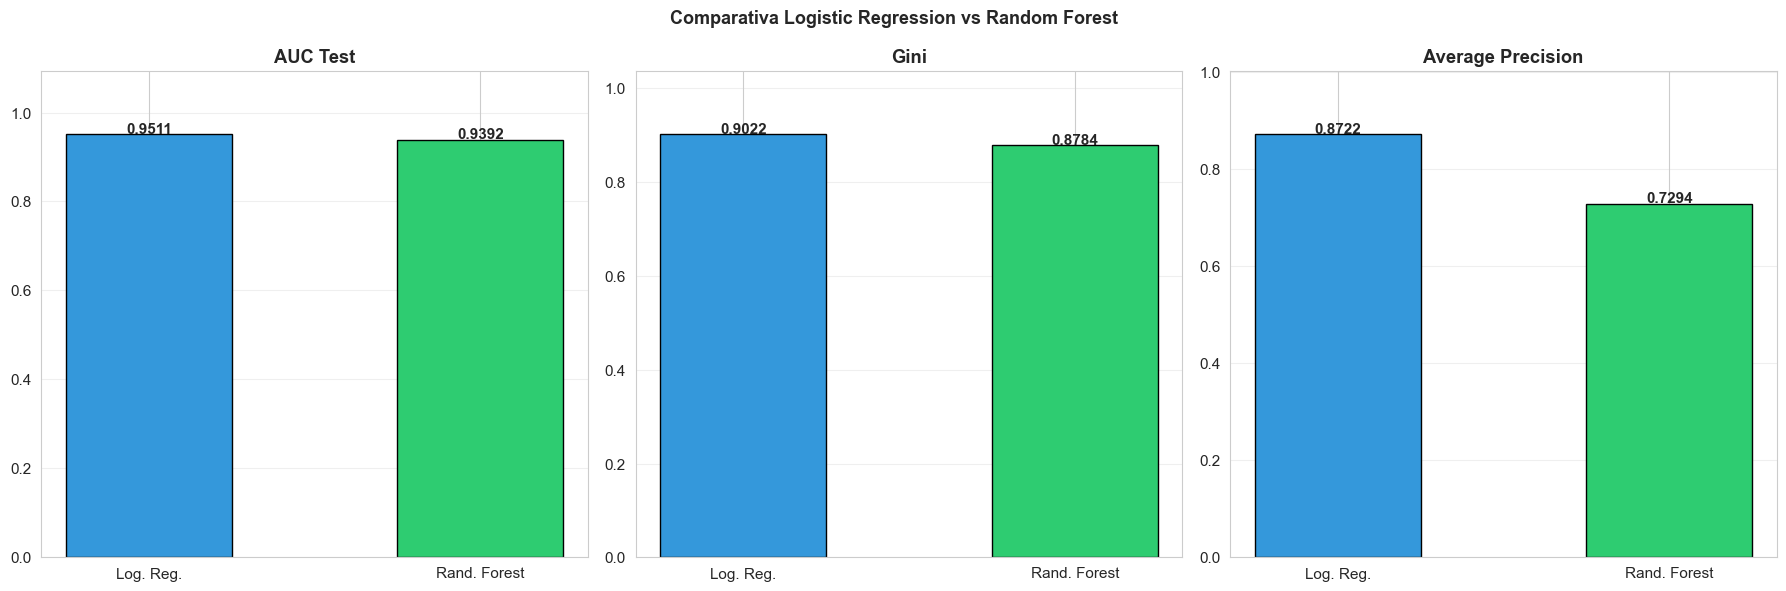


RECOMENDACION:
- Logistic Regression: cuando la interpretabilidad es critica (Basilea, regulador)
- Random Forest: cuando la precision es prioritaria y se puede justificar el modelo
- En banca, ambos son aceptados; RF requiere mas documentacion de interpretabilidad


In [12]:
# Comparativa sistematica de los dos modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_pipe = Pipeline([('scaler', StandardScaler()),
                     ('lr', LogisticRegression(C=1.0, class_weight='balanced',
                                               solver='lbfgs', max_iter=500, random_state=RANDOM_STATE))])
rf_pipe = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)

resultados = {}
for nombre, modelo in [('Logistic Regression', lr_pipe), ('Random Forest', rf_pipe)]:
    t0 = time.time()
    cv_aucs = cross_val_score(modelo, X, y, cv=cv, scoring='roc_auc')
    t_cv = time.time() - t0
    modelo.fit(X_train, y_train)
    t1 = time.time()
    y_p = modelo.predict_proba(X_test)[:,1]
    t_inf = (time.time()-t1)*1000  # ms por batch
    resultados[nombre] = {
        'AUC_CV_Media': cv_aucs.mean(), 'AUC_CV_Std': cv_aucs.std(),
        'AUC_Test': roc_auc_score(y_test, y_p),
        'Gini': 2*roc_auc_score(y_test, y_p)-1,
        'AP': average_precision_score(y_test, y_p),
        'Brier': brier_score_loss(y_test, y_p),
        'T_train_seg': t_cv, 'T_inf_ms': t_inf
    }

comp_df = pd.DataFrame(resultados).T
print("\nCOMPARATIVA: Regresion Logistica vs Random Forest")
print("="*65)
print(comp_df.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metricas = ['AUC_Test', 'Gini', 'AP']
nombres_met = ['AUC Test', 'Gini', 'Average Precision']
for ax, met, nm in zip(axes, metricas, nombres_met):
    vals = [resultados['Logistic Regression'][met], resultados['Random Forest'][met]]
    bars = ax.bar(['Log. Reg.', 'Rand. Forest'], vals, color=['#3498db','#2ecc71'], edgecolor='black', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{v:.4f}', ha='center', fontweight='bold')
    ax.set_title(nm, fontweight='bold'); ax.set_ylim(0, max(vals)*1.15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparativa Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nRECOMENDACION:")
print("- Logistic Regression: cuando la interpretabilidad es critica (Basilea, regulador)")
print("- Random Forest: cuando la precision es prioritaria y se puede justificar el modelo")
print("- En banca, ambos son aceptados; RF requiere mas documentacion de interpretabilidad")

---
# EJERCICIOS PRACTICOS PARA AUDITORES
---

### EJERCICIO 1: Scoring de Credito PYME con OOB Validation

**Contexto:** El banco necesita un modelo de scoring para PYMEs con solo 2.000 casos disponibles.  
**Tareas:** (1) RF con oob_score=True y justifica su valor con datos escasos. (2) Compara OOB vs AUC test. (3) Analiza top-5 variables con MDI y permutacion. (4) Analiza errores FP/FN por sector. (5) Umbral optimo minimizando perdidas: LGD=0.45, tasa_interes=8%.

In [ ]:
np.random.seed(101)
n = 2000
df_pyme = pd.DataFrame({
    'anos_empresa': np.random.exponential(6, n).clip(0.5, 30),
    'facturacion_anual': np.random.lognormal(12, 1.2, n).clip(50000, 10000000),
    'num_empleados': np.random.lognormal(2.5, 1.0, n).clip(1, 500).astype(int),
    'ratio_deuda_activo': np.random.uniform(0.1, 0.9, n),
    'ratio_cobertura_intereses': np.random.lognormal(1.0, 0.8, n).clip(0, 20),
    'crecimiento_ventas_pct': np.random.normal(0.05, 0.20, n),
    'ratio_liquidez': np.random.lognormal(0.3, 0.5, n).clip(0.1, 5),
    'sector': np.random.choice(['Construccion','Hosteleria','Industria','Comercio','Servicios','Agro'],
                                n, p=[0.15,0.15,0.20,0.20,0.25,0.05]),
    'score_comportamiento': np.random.normal(650, 90, n).clip(300, 850).astype(int),
    'num_impagados_proveedores': np.random.choice([0,1,2,3,4], n, p=[0.65,0.18,0.10,0.05,0.02]),
    'tiene_auditoria_externa': np.random.choice([0,1], n, p=[0.55,0.45]),
    'garantia_real_pct': np.random.uniform(0, 1.5, n),
    'anos_relacion_banco': np.random.exponential(4, n).clip(0, 25),
})
log_odds_pyme = (
    -4.0 - 0.08*df_pyme['anos_empresa']
    + 1.8*(df_pyme['ratio_deuda_activo']-0.6).clip(0)
    - 0.5*df_pyme['ratio_cobertura_intereses'].clip(0,5)
    - 0.003*(df_pyme['score_comportamiento']-500)
    + 0.6*df_pyme['num_impagados_proveedores']
    + 0.5*df_pyme['sector'].isin(['Construccion','Hosteleria']).astype(int)
    - 0.4*df_pyme['tiene_auditoria_externa'] - 0.6*df_pyme['garantia_real_pct']
    - 0.5*df_pyme['ratio_liquidez'].clip(0,3) - 0.04*df_pyme['anos_relacion_banco']
)
prob_pyme = 1/(1+np.exp(-log_odds_pyme))
df_pyme[TARGET] = (np.random.uniform(0,1,n) < prob_pyme).astype(int)
print(f"PYMEs: {len(df_pyme):,} | Default: {df_pyme[TARGET].mean()*100:.1f}%")
df_pyme.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 1
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 2: Deteccion de Fraude con RF y Clases Desbalanceadas

**Contexto:** El fraude es el 0.8% del total. El banco quiere capturar al menos el 85% de fraudes.  
**Tareas:** (1) Analiza curva PR vs ROC para datos desbalanceados. (2) Compara class_weight=balanced vs SMOTE. (3) Umbral que captura 85% fraudes. (4) ROI: fraude_medio=3200€, coste_revision=30€. (5) Curva coste-beneficio por umbral.

In [ ]:
np.random.seed(202)
n_trans = 20000
df_fraude = pd.DataFrame({
    'importe': np.random.lognormal(5, 1.5, n_trans).clip(1, 25000),
    'hora': np.random.randint(0, 24, n_trans),
    'pais_riesgo': np.random.choice([0,1], n_trans, p=[0.85,0.15]),
    'num_trans_1h': np.random.poisson(2, n_trans).clip(1, 30),
    'importe_desv_perfil': np.random.exponential(0.8, n_trans).clip(0, 15),
    'comercio_nuevo': np.random.choice([0,1], n_trans, p=[0.55,0.45]),
    'tarjeta_nueva_30d': np.random.choice([0,1], n_trans, p=[0.88,0.12]),
    'pin_incorrecto_previo': np.random.choice([0,1], n_trans, p=[0.92,0.08]),
    'geolocalizacion_distante': np.random.choice([0,1], n_trans, p=[0.80,0.20]),
    'dispositivo_nuevo': np.random.choice([0,1], n_trans, p=[0.75,0.25]),
    'velocidad_trans_hora': np.random.exponential(0.5, n_trans).clip(0, 10),
})
log_odds_fr = (
    -7.0 + 0.0001*df_fraude['importe'] + 0.6*(df_fraude['hora']<6).astype(int)
    + 2.0*df_fraude['pais_riesgo'] + 0.3*df_fraude['num_trans_1h']
    + 1.5*df_fraude['importe_desv_perfil'] + 0.7*df_fraude['comercio_nuevo']
    + 1.8*df_fraude['tarjeta_nueva_30d'] + 2.0*df_fraude['pin_incorrecto_previo']
    + 1.2*df_fraude['geolocalizacion_distante'] + 0.8*df_fraude['dispositivo_nuevo']
    + 0.8*df_fraude['velocidad_trans_hora']
)
prob_fr = 1/(1+np.exp(-log_odds_fr))
df_fraude['fraude'] = (np.random.uniform(0,1,n_trans) < prob_fr).astype(int)
print(f"Trans: {len(df_fraude):,} | Fraudes: {df_fraude['fraude'].sum()} ({df_fraude['fraude'].mean()*100:.2f}%)")
df_fraude.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 2
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 3: Seleccion de Variables — De 50 a 15

**Contexto:** El regulador pide reducir el modelo de 50 a maximo 15 variables sin perder rendimiento.  
**Tareas:** (1) RF con 50 variables. (2) Curva acumulada de importancia con punto de codo. (3) Modelos reducidos (top-5,10,15,20,30) comparando AUC. (4) Selecciona conjunto con AUC>=0.98xAUC_full. (5) Justificacion de negocio de las variables elegidas.

In [ ]:
np.random.seed(303)
n = 5000
df_base = generar_portafolio_bancario(n=n, seed=33)
X_base, y_base = preparar_X_y_desde_df(df_base)

# Añadimos variables de ruido para demostrar la capacidad del RF de priorizar señales reales
df_reduccion = pd.DataFrame({f'ruido_{i:02d}': np.random.normal(0,1,n) for i in range(35)})
for col in X_base.columns:
    df_reduccion[col] = X_base[col].values
df_reduccion[TARGET] = y_base.values

print(f"Dataset: {len(df_reduccion):,} | Variables: {df_reduccion.shape[1]-1} ({X_base.shape[1]} reales + 35 ruido)")
print(f"Riesgo auditoría: {df_reduccion[TARGET].mean()*100:.1f}%")

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 3
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 4: Perdida Esperada IFRS 9 con Random Forest

**Contexto:** El banco usa RF para estimar PD, LGD y EAD. Calcula provisiones IFRS 9.  
**Tareas:** (1) Tres RF separados: PD (clasificacion), LGD (regresion), EAD (regresion). (2) EL=PD*LGD*EAD por cliente. (3) Provisiones por Stage IFRS9. (4) Compara vs provisiones contables actuales. (5) Stress test +20% PD.

In [ ]:
np.random.seed(404)
n_el = 5000
df_el = generar_portafolio_bancario(n=n_el, seed=44)

# Exposición estimada: aproximación basada en importe de operación y saldo medio del cliente
df_el['ead'] = (
    df_el['importe_operacion'].clip(lower=100) * np.random.uniform(1.5, 4.0, n_el)
    + 0.02 * df_el['saldo_medio_cliente'].clip(lower=0)
).clip(500, 800000)

# LGD sintética para fines docentes, usando variables disponibles en el nuevo dataset
df_el['lgd_target'] = (
    0.35
    + 0.10 * df_el['ratio_ingresos_deuda'].clip(0, 3)
    + 0.08 * (df_el['pais_riesgo'] == 'alto').astype(int)
    + 0.06 * (df_el['segmento_riesgo_cliente'] == 'alto').astype(int)
    + np.random.normal(0, 0.06, n_el)
).clip(0.05, 0.95)

# Stage IFRS9 aproximado con alertas previas y tiempo desde última revisión
df_el['stage'] = np.where(
    (df_el['num_alertas_previas'] >= 3) | (df_el['dias_desde_ultima_revision'] > 240), 'Stage3',
    np.where((df_el['num_alertas_previas'] >= 1) | (df_el['dias_desde_ultima_revision'] > 120), 'Stage2', 'Stage1')
)

df_el['provision_contable'] = df_el['ead'] * np.where(
    df_el['stage']=='Stage1', 0.01, np.where(df_el['stage']=='Stage2', 0.06, 0.40)
) * np.random.uniform(0.85, 1.15, n_el)

print("IFRS 9 por Stage:")
print(df_el.groupby('stage')[[TARGET,'lgd_target','ead']].mean().round(3))
print(f"\nProvision contable total: {df_el['provision_contable'].sum():,.0f}€")
df_el.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 4
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 5: Backtesting Trimestral y Plan de Reentrenamiento

**Contexto:** El modelo lleva 6 trimestres en produccion. Se detecta deriva en el portafolio.  
**Tareas:** (1) Simula 6 trimestres con deriva gradual. (2) PSI y AUC por trimestre. (3) Detecta cuándo reentrenar. (4) Reentrenar con datos acumulados y comparar. (5) Protocolo de monitoreo con alertas.

In [ ]:
np.random.seed(505)
deterioros_q = [0.0, 0.04, 0.09, 0.16, 0.25, 0.35]
trimestres = {}
for q, det in enumerate(deterioros_q, 1):
    df_q = generar_portafolio_bancario(n=1500, seed=q*10)

    if 'score_crediticio' in df_q.columns:
        df_q['score_crediticio'] = (df_q['score_crediticio']*(1-det)).clip(300,850)
    if 'ratio_ingresos_deuda' in df_q.columns:
        df_q['ratio_ingresos_deuda'] = df_q['ratio_ingresos_deuda']*(1+det*0.8)
    if 'num_alertas_previas' in df_q.columns:
        df_q['num_alertas_previas'] = (df_q['num_alertas_previas'] + np.random.binomial(2, det, len(df_q))).astype(int)

    trimestres[f'Q{q}'] = df_q
    print(
        f"Q{q}: riesgo auditoría={df_q[TARGET].mean()*100:.1f}% | "
        f"score medio={df_q['score_crediticio'].mean():.0f} | deterioro={det*100:.0f}%"
    )

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 5
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 6: Churn Bancario con RF y Señales de Comportamiento

**Contexto:** El banco predice abandono en 90 dias usando señales transaccionales.  
**Tareas:** (1) RF y analiza señales de comportamiento predictivas. (2) 4 segmentos de riesgo churn. (3) Ranking top-200 en riesgo con score y principal driver. (4) Revenue en riesgo por segmento. (5) Campaña de retencion por segmento.

In [ ]:
np.random.seed(606)
n_churn = 8000
df_churn = pd.DataFrame({
    'antiguedad_anos': np.random.exponential(5, n_churn).clip(0.1,30),
    'num_productos': np.random.poisson(2.2, n_churn).clip(1,8),
    'saldo_medio_6m': np.random.lognormal(7.5, 1.2, n_churn).clip(0,100000),
    'variacion_saldo_3m': np.random.normal(-0.05, 0.30, n_churn),
    'transacciones_mes': np.random.poisson(18, n_churn).clip(0,150),
    'variacion_trans_3m': np.random.normal(-0.08, 0.35, n_churn),
    'dias_ultimo_acceso_app': np.random.exponential(12, n_churn).clip(0,180).astype(int),
    'num_quejas_12m': np.random.choice([0,1,2,3,4,5], n_churn, p=[0.60,0.20,0.10,0.05,0.03,0.02]),
    'nps_score': np.random.choice(range(-100,101,10), n_churn),
    'tiene_hipoteca': np.random.choice([0,1], n_churn, p=[0.55,0.45]),
    'tiene_seguro': np.random.choice([0,1], n_churn, p=[0.50,0.50]),
    'tiene_pension': np.random.choice([0,1], n_churn, p=[0.65,0.35]),
    'canal_principal': np.random.choice(['App','Web','Oficina','Telefono'], n_churn, p=[0.40,0.30,0.20,0.10]),
    'segmento_valor': np.random.choice(['Mass','Affluent','Private'], n_churn, p=[0.65,0.28,0.07]),
    'meses_sin_transaccionar': np.random.choice([0,1,2,3,4,5,6], n_churn, p=[0.65,0.15,0.09,0.05,0.03,0.02,0.01]),
})
log_odds_churn = (
    -2.5 - 0.10*df_churn['antiguedad_anos'] - 0.35*df_churn['num_productos']
    - 0.000003*df_churn['saldo_medio_6m'] - 1.8*df_churn['variacion_saldo_3m']
    + 0.025*df_churn['dias_ultimo_acceso_app'] + 0.60*df_churn['num_quejas_12m']
    - 0.012*df_churn['nps_score'] - 0.90*df_churn['tiene_hipoteca']
    - 0.55*df_churn['tiene_seguro'] - 0.70*df_churn['tiene_pension']
    - 1.20*(df_churn['variacion_trans_3m']>0).astype(int)
    + 0.40*df_churn['meses_sin_transaccionar']
)
prob_churn = 1/(1+np.exp(-log_odds_churn))
df_churn['churn'] = (np.random.uniform(0,1,n_churn) < prob_churn).astype(int)
df_churn['aum'] = df_churn['saldo_medio_6m'] * np.random.uniform(1.0, 8.0, n_churn)
print(f"Churn: {len(df_churn):,} clientes | Tasa abandono: {df_churn['churn'].mean()*100:.1f}%")
print(f"AUM total: {df_churn['aum'].sum():,.0f}€")
df_churn.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 6
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 7: Auditoria de Modelo RF Externo — Validacion de Proveedor

**Contexto:** El banco ha contratado un RF a proveedor externo. Debes validarlo como auditor.  
**Tareas:** (1) Valida AUC, KS, Gini en el portafolio del banco. (2) Verifica calibracion. (3) Detecta sesgos por genero, edad y region. (4) Construye tu propio RF y compara. (5) Dictamen auditoria con evidencias cuantitativas.

In [ ]:
np.random.seed(707)
n_val = 5000
df_val = generar_portafolio_bancario(n=n_val, seed=77)
df_val['genero'] = np.random.choice(['M','F'], n_val, p=[0.52,0.48])
df_val['region'] = np.random.choice(['Norte','Sur','Este','Oeste','Centro'], n_val)

# Modelo externo con posible sesgo de género. Se usa score_crediticio del nuevo dataset.
score_prov = 700 - 0.25*(700-df_val['score_crediticio'])
score_prov += np.where(df_val['genero']=='F', -25, 0)
score_prov += np.random.normal(0, 20, n_val)
df_val['score_proveedor'] = score_prov.clip(300,850).astype(int)
df_val['prob_proveedor'] = 1/(1+np.exp((df_val['score_proveedor']-600)/60))

print(f"Validacion: {n_val:,} operaciones | Riesgo auditoría: {df_val[TARGET].mean()*100:.1f}%")
print(f"Score hombres: {df_val[df_val['genero']=='M']['score_proveedor'].mean():.0f} | mujeres: {df_val[df_val['genero']=='F']['score_proveedor'].mean():.0f}")
df_val.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 7
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 8: RF para Riesgo Operacional — Clasificacion de Severidad

**Contexto:** El banco quiere clasificar eventos OpRisk en 4 niveles de severidad segun Basilea IV.  
**Tareas:** (1) RF multiclase para 4 niveles de severidad. (2) Matriz confusion multiclase y AUC macro. (3) Analiza categorias mas dificiles de predecir. (4) Capital regulatorio con las probabilidades del modelo. (5) Informe OpRisk para el regulador.

In [ ]:
np.random.seed(808)
n_oprisk = 6000
df_oprisk = pd.DataFrame({
    'linea_negocio': np.random.choice(['Banca_Retail','Banca_Corp','Tesoreria','Pagos','Custodia'],
                                       n_oprisk, p=[0.35,0.25,0.15,0.15,0.10]),
    'categoria_riesgo': np.random.choice(['Fraude_Ext','Fraude_Int','Fallo_Sistemas','Error_Proceso','Externo'],
                                          n_oprisk, p=[0.30,0.15,0.25,0.20,0.10]),
    'num_controles_fallidos': np.random.choice([0,1,2,3,4,5], n_oprisk, p=[0.55,0.22,0.12,0.06,0.03,0.02]),
    'antiguedad_proceso_anos': np.random.exponential(5, n_oprisk).clip(0.1,25),
    'num_empleados_area': np.random.lognormal(3,1,n_oprisk).clip(2,500).astype(int),
    'horas_fuera_ventana': np.random.exponential(2, n_oprisk).clip(0,48),
    'volumen_operaciones_dia': np.random.lognormal(6,1.5,n_oprisk).clip(10,100000),
    'incidentes_previos_12m': np.random.choice([0,1,2,3,4], n_oprisk, p=[0.55,0.25,0.12,0.05,0.03]),
    'tiene_plan_contingencia': np.random.choice([0,1], n_oprisk, p=[0.30,0.70]),
    'ultima_auditoria_meses': np.random.exponential(12, n_oprisk).clip(1,60).astype(int),
})
score_riesgo = (
    + 0.8*df_oprisk['num_controles_fallidos'] - 0.05*df_oprisk['antiguedad_proceso_anos']
    + 0.0005*df_oprisk['volumen_operaciones_dia'] + 0.6*df_oprisk['incidentes_previos_12m']
    + 0.3*df_oprisk['horas_fuera_ventana'] - 0.5*df_oprisk['tiene_plan_contingencia']
    + 0.02*df_oprisk['ultima_auditoria_meses']
    + 0.5*df_oprisk['categoria_riesgo'].isin(['Fraude_Int','Externo']).astype(int)
)
df_oprisk['severidad'] = pd.cut(score_riesgo + np.random.normal(0,0.5,n_oprisk),
                                  bins=[-np.inf,0.5,1.5,2.5,np.inf], labels=[0,1,2,3]).astype(int)
sev_names = {0:'Baja',1:'Media',2:'Alta',3:'Critica'}
print("Distribución de severidad OpRisk:")
for k,v in sev_names.items():
    n_s = (df_oprisk['severidad']==k).sum()
    print(f"  {v}: {n_s:,} ({n_s/n_oprisk*100:.1f}%)")
df_oprisk.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 8
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 9: RF para Deteccion de Blanqueo de Capitales (AML)

**Contexto:** El departamento de Cumplimiento necesita priorizar operaciones sospechosas de AML.  
**Tareas:** (1) RF para detectar operaciones AML con variables de comportamiento y contexto. (2) Curva de lift y ganancia — cuantas operaciones revisar para capturar el 80% de sospechosas. (3) Genera ranking de prioridad para el equipo de cumplimiento. (4) Analiza variables proxy de paises de riesgo y sectores sensibles. (5) Documenta el modelo para el regulador con explicacion de cada variable.

In [ ]:
np.random.seed(909)
n_aml = 10000
paises_riesgo_aml = ['Panama','Islas_Cayman','Rusia','UAE','Lichtenstein']
sectores_riesgo_aml = ['Inmobiliario','Hosteleria','Joyeria','Arte']

df_aml = pd.DataFrame({
    'importe': np.random.lognormal(8, 1.8, n_aml).clip(100, 2000000),
    'num_ops_mismo_dia': np.random.poisson(2, n_aml).clip(1, 30),
    'pais_origen': np.random.choice(['España','Alemania','UK','Panama','Rusia','UAE','Islas_Cayman','Francia'],
                                     n_aml, p=[0.35,0.15,0.12,0.08,0.08,0.07,0.06,0.09]),
    'sector_economico': np.random.choice(['Inmobiliario','Hosteleria','Industria','Comercio','Joyeria','Arte'],
                                          n_aml, p=[0.20,0.18,0.20,0.22,0.10,0.10]),
    'edad_cuenta_meses': np.random.exponential(24, n_aml).clip(1,240).astype(int),
    'ops_redondas_30d': np.random.poisson(0.5, n_aml).clip(0, 15),
    'variacion_vs_media': np.random.exponential(0.4, n_aml).clip(0, 10),
    'hora_operacion': np.random.randint(0, 24, n_aml),
    'fraccionamiento': np.random.choice([0,1], n_aml, p=[0.85,0.15]),
    'num_titulares': np.random.choice([1,2,3,4,5], n_aml, p=[0.60,0.25,0.10,0.03,0.02]),
})
df_aml['pais_riesgo'] = df_aml['pais_origen'].isin(paises_riesgo_aml).astype(int)
df_aml['sector_riesgo'] = df_aml['sector_economico'].isin(sectores_riesgo_aml).astype(int)

log_odds_aml = (
    -6.5 + 0.0000005*df_aml['importe'] + 0.15*df_aml['num_ops_mismo_dia']
    + 2.2*df_aml['pais_riesgo'] + 1.0*df_aml['sector_riesgo']
    - 0.012*df_aml['edad_cuenta_meses'] + 0.6*df_aml['ops_redondas_30d']
    + 1.8*df_aml['variacion_vs_media'] + 0.6*(df_aml['hora_operacion']<7).astype(int)
    + 2.0*df_aml['fraccionamiento'] + 0.4*(df_aml['num_titulares']>2).astype(int)
)
prob_aml = 1/(1+np.exp(-log_odds_aml))
df_aml['sospechoso'] = (np.random.uniform(0,1,n_aml) < prob_aml).astype(int)
print(f"AML: {len(df_aml):,} ops | Sospechosas: {df_aml['sospechoso'].sum()} ({df_aml['sospechoso'].mean()*100:.1f}%)")
df_aml.head()

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 9
raise NotImplementedError("Completa este ejercicio")

### EJERCICIO 10: Dashboard Completo de Auditoria del Random Forest

**Contexto:** El Comite de Riesgos solicita el informe completo de validacion del modelo RF.  
**Produce el informe completo:**
1. Arquitectura: hiperparametros, variables, version del modelo
2. Calidad de datos: completitud, outliers, distribuciones por variable
3. Rendimiento: AUC, KS, Gini, Precision-Recall, Calibracion, Brier Score
4. Estabilidad: PSI trimestral, deriva de las top-5 variables
5. Equidad: tasas de denegacion por genero, edad y region
6. Backtesting: tasas default predichas vs reales por cohorte
7. Semaforo por seccion: OK / REVISAR / REENTRENAR
8. Plan de accion: recomendaciones priorizadas, responsables y plazos

In [ ]:
print("Datasets disponibles:")
print(f"  df        -> Portafolio principal ({len(df):,} clientes)")
print(f"  df_pyme   -> PYMEs ({len(df_pyme):,} empresas)")
print(f"  df_fraude -> Fraude ({len(df_fraude):,} transacciones)")
print(f"  df_val    -> Validacion modelo externo ({len(df_val):,} clientes)")
print(f"  df_churn  -> Churn bancario ({len(df_churn):,} clientes)")
print(f"  df_aml    -> AML operaciones ({len(df_aml):,} operaciones)")
print("\nModelo disponible: rf_opt (Random Forest optimo entrenado y evaluado)")

In [ ]:
# TU SOLUCION AQUI — EJERCICIO 10 (INTEGRADOR)
raise NotImplementedError("Completa este ejercicio integrador")

---
## RESUMEN Y REFERENCIAS

### Checklist de Auditoria — Random Forest

| Aspecto | Metrica | Umbral Bancario |
|---------|---------|----------------|
| Discriminacion | AUC | > 0.75 |
| Discriminacion | Gini | > 50% |
| Discriminacion | KS | > 0.40 |
| Estabilidad | PSI | < 0.10 |
| Calibracion | Brier Score | < 0.10 |
| Consistencia | OOB vs Test gap | < 0.02 |
| Parsimonia | Top-5 importancia acumulada | > 60% |

### Hiperparametros Recomendados en Banca

| Parametro | Valor Recomendado |
|-----------|------------------|
| n_estimators | 200-300 |
| max_features | 'sqrt' |
| min_samples_leaf | 10-20 |
| class_weight | 'balanced' |
| oob_score | True |

---
*Notebook desarrollado para el programa de formacion en analitica avanzada para auditores bancarios*